# Saudi (Tadawul) 20-Day Neutral-vs-Extreme Labels & Model

The Saudi-market counterpart to `20_Days_labels_binary_extreme.ipynb`. Same overall approach --
Optuna-tuned XGBoost binary classifier, collapsing a magnitude-based label into `Neutral` vs.
`Extreme`, time-embargoed split -- applied to a different universe with a different feature
catalogue, because the source data is different in kind, not just in market:

- **US notebook**: 188 ETFs / 35 categories, 12 hand/`pandas-ta`-engineered features
  (`peer_rank_20d`, `beta_60d`, RSI/StochRSI/Bollinger/CCI/PGO/Fisher indicators z-scored within
  category), label from `fwd_relative_return`'s 15th/85th percentiles.
- **This notebook**: 12 Tadawul-listed funds (`9400.SR`-`9411.SR`), the 42 scale-free features
  `core.py` already builds for the US<->Saudi transfer experiment (`saudi.py`) -- technical
  indicators, cross-sectional ranks, and market-context features, all unitless so they transfer
  across markets. Label from the same 15th/85th-percentile-of-`rel` construction, `rel` being
  each fund's 20-day forward return in excess of the equal-weight Saudi universe that day (the
  same quantity `core.panel()` already computes).

Data: `data/processed/transfer/saudi.parquet`, built by `saudi.py --build` (12 funds,
2024-01-01 to the latest cached date, ~600 trading days). No category grouping exists for this
universe -- `core.panel()` uses one pooled peer group ("all") since there's no Tadawul-fund
categorization the way `financedatabase` provides for US ETFs.

Backtested against **TASI** (and the FALCOM Saudi Equity ETF) instead of SPY.

In [1]:
import pathlib
import sys

ROOT = pathlib.Path(r"C:\Users\user\Desktop\CS\overp\outperforming")
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

data_path = ROOT / "data" / "processed" / "transfer" / "saudi.parquet"
sa = pd.read_parquet(data_path)

print("Loaded:", data_path)
print("Rows:", len(sa))
print("Date range:", sa.index.get_level_values("date").min(), "to", sa.index.get_level_values("date").max())
print("Tickers:", sorted(sa.index.get_level_values("ticker").unique()))

Loaded: C:\Users\user\Desktop\CS\overp\outperforming\data\processed\transfer\saudi.parquet
Rows: 6087
Date range: 2024-01-01 00:00:00 to 2026-06-29 00:00:00
Tickers: ['9400.SR', '9401.SR', '9402.SR', '9403.SR', '9404.SR', '9405.SR', '9406.SR', '9407.SR', '9408.SR', '9409.SR', '9410.SR', '9411.SR']


## Feature engineering (already computed)

All 42 features come straight from `core.features()` -- the same scale-free feature set
`saudi.py`'s transfer experiment trains on, so this notebook and the app's Saudi tab are looking
at the same numbers. `LABEL_COLS` (`fwd_ret`, `adv`, `rel`, `target`) are the label-side columns
`core.panel()` appends and are excluded from the feature list.

In [2]:
LABEL_COLS = ["fwd_ret", "adv", "rel", "target"]
feature_cols = [c for c in sa.columns if c not in LABEL_COLS]

print("n features:", len(feature_cols))
print(feature_cols)
print()
print("NaN counts per feature (expected: warm-up window rows per fund):")
print(sa[feature_cols].isna().sum().sort_values(ascending=False).head(10))
print()
print("Rows with all features populated:", sa[feature_cols].notna().all(axis=1).sum(), "of", len(sa))

n features: 42
['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'ema20_dist', 'ema50_dist', 'macd', 'macd_signal', 'macd_hist', 'adx_14', 'rsi_14', 'willr_14', 'bb_pctb', 'stoch_k', 'stoch_d', 'vol_20d', 'vol_zscore', 'bb_bandwidth', 'atr_14', 'beta_60d', 'mfi_14', 'cmf_20', 'rel_volume_20d', 'cs_rank_ret_5d', 'cs_rank_ret_20d', 'cs_rank_rsi', 'cs_rank_volatility', 'cs_rank_volume', 'peer_rank_20d', 'd_rsi_5d', 'd_peer_rank_5d', 'd_vol_5d', 'd_macd_hist_5d', 'd_volume_pct_5d', 'cat_ret_5d', 'cat_disp_5d', 'beat_rate_20d', 'mkt_ret_1d', 'mkt_vol_20d', 'mkt_vol_zscore', 'breadth_50d']

NaN counts per feature (expected: warm-up window rows per fund):
beta_60d              767
vol_zscore            255
ret_60d               172
d_vol_5d              124
d_peer_rank_5d         53
cs_rank_ret_20d        22
ret_20d                22
cs_rank_volatility     22
vol_20d                22
peer_rank_20d          22
dtype: int64

Rows with all features populated: 5241 of 6087


## Label construction: 15th/85th percentile of `rel`, same shape as the US notebook

`rel` is each fund's realized 20-trading-day forward return minus the equal-weight Saudi
universe's mean that day -- already computed by `core.panel()`, the same peer-relative
construction `fwd_relative_return` is in the US dataset. Percentile cutoffs are taken over the
**whole sample** before the train/val/test split, exactly matching the US notebook's own
methodology (its `valid_fwd.quantile(0.15/0.85)` cell runs before the split too) -- consistent
treatment, not a new source of leakage relative to the reference notebook.

In [3]:
valid_rel = sa["rel"].dropna()
lower_q = valid_rel.quantile(0.15)
upper_q = valid_rel.quantile(0.85)
print("Underperform-side cutoff (15th pct):", round(lower_q * 100, 3), "%")
print("Outperform-side cutoff (85th pct):", round(upper_q * 100, 3), "%")

sa["binary_label"] = np.where(sa["rel"] < lower_q, "Extreme",
                       np.where(sa["rel"] > upper_q, "Extreme", "Neutral"))
sa.loc[sa["rel"].isna(), "binary_label"] = np.nan

labeled = sa["binary_label"].dropna()
print()
print("Labeled rows:", len(labeled), "of", len(sa))
print(labeled.value_counts())
print((labeled.value_counts(normalize=True) * 100).round(2))

Underperform-side cutoff (15th pct): -3.781 %
Outperform-side cutoff (85th pct): 3.603 %

Labeled rows: 6087 of 6087
binary_label
Neutral    4261
Extreme    1826
Name: count, dtype: int64
binary_label
Neutral    70.0
Extreme    30.0
Name: proportion, dtype: float64


## Modeling: XGBoost with Optuna hyperparameter tuning (60 trials)

Time-based 70/15/15 train/val/test split by unique date, with a 20-trading-day embargo gap after
each boundary -- identical logic and identical embargo length to the US notebook (the label
horizon is 20 days there too). The Saudi universe is much smaller (~600 trading days vs. ~5
years for the US set), so the val/test windows are correspondingly thin -- flagged here rather
than hidden, since it's the honest caveat on anything this notebook concludes.

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight

label_map = {"Neutral": 0, "Extreme": 1}
inv_label_map = {v: k for k, v in label_map.items()}

model_df = sa.dropna(subset=feature_cols + ["binary_label"]).copy()
model_df["label_enc"] = model_df["binary_label"].map(label_map)

print("Modeling rows:", len(model_df), "of", len(sa))
print(model_df["binary_label"].value_counts())

Modeling rows: 5241 of 6087
binary_label
Neutral    3638
Extreme    1603
Name: count, dtype: int64


In [5]:
EMBARGO_DAYS = 20
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15

dates_idx = model_df.index.get_level_values("date")
unique_dates = np.sort(dates_idx.unique())
n_dates = len(unique_dates)

train_end_i = int(n_dates * TRAIN_FRAC)
val_end_i = int(n_dates * (TRAIN_FRAC + VAL_FRAC))

train_dates = unique_dates[:train_end_i]
val_dates = unique_dates[train_end_i + EMBARGO_DAYS: val_end_i]
test_dates = unique_dates[val_end_i + EMBARGO_DAYS:]

train_df = model_df[dates_idx.isin(train_dates)]
val_df = model_df[dates_idx.isin(val_dates)]
test_df = model_df[dates_idx.isin(test_dates)]

print("Train:", pd.Timestamp(train_dates.min()).date(), "to", pd.Timestamp(train_dates.max()).date(), "-", len(train_df), "rows")
print("Val:  ", pd.Timestamp(val_dates.min()).date(), "to", pd.Timestamp(val_dates.max()).date(), "-", len(val_df), "rows")
print("Test: ", pd.Timestamp(test_dates.min()).date(), "to", pd.Timestamp(test_dates.max()).date(), "-", len(test_df), "rows")
print("Embargo gap:", EMBARGO_DAYS, "trading days after each split boundary")

X_train, y_train = train_df[feature_cols].values, train_df["label_enc"].values
X_val, y_val = val_df[feature_cols].values, val_df["label_enc"].values
X_test, y_test = test_df[feature_cols].values, test_df["label_enc"].values

print()
print("Class distribution (train):"); print(train_df["binary_label"].value_counts(normalize=True).round(3))
print("Class distribution (val):");   print(val_df["binary_label"].value_counts(normalize=True).round(3))
print("Class distribution (test):");  print(test_df["binary_label"].value_counts(normalize=True).round(3))

Train: 2024-01-01 to 2025-10-22 - 3382 rows
Val:   2025-11-20 to 2026-02-16 - 636 rows
Test:  2026-03-25 to 2026-06-29 - 756 rows
Embargo gap: 20 trading days after each split boundary

Class distribution (train):
binary_label
Neutral    0.702
Extreme    0.298
Name: proportion, dtype: float64
Class distribution (val):
binary_label
Neutral    0.761
Extreme    0.239
Name: proportion, dtype: float64
Class distribution (test):
binary_label
Neutral    0.657
Extreme    0.343
Name: proportion, dtype: float64


In [6]:
import optuna
import xgboost as xgb

sw_train = compute_sample_weight(class_weight="balanced", y=y_train)

def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, sample_weight=sw_train)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average="macro")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=60, show_progress_bar=True)

print("Best validation macro F1:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(" ", k, "=", v)

C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/60 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.656775:   0%|          | 0/60 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.656775:   2%|▏         | 1/60 [00:00<00:57,  1.03it/s]

Best trial: 1. Best value: 0.667637:   2%|▏         | 1/60 [00:01<00:57,  1.03it/s]

...

Best trial: 56. Best value: 0.686985:  98%|█████████▊| 59/60 [03:15<00:03,  3.89s/it]

Best trial: 56. Best value: 0.686985:  98%|█████████▊| 59/60 [03:19<00:03,  3.89s/it]

Best trial: 56. Best value: 0.686985: 100%|██████████| 60/60 [03:19<00:00,  3.92s/it]

Best trial: 56. Best value: 0.686985: 100%|██████████| 60/60 [03:19<00:00,  3.32s/it]

Best validation macro F1: 0.6869852206765774
Best params:
  max_depth = 7
  learning_rate = 0.04126941674781365
  n_estimators = 392
  subsample = 0.9310316183126517
  colsample_bytree = 0.6788736361640635
  min_child_weight = 4
  reg_alpha = 0.025493224887214092
  reg_lambda = 0.30509294712424034


XGBoost model (Saudi) - test set performance
              precision    recall  f1-score   support

     Neutral      0.694     0.881     0.777       497
     Extreme      0.528     0.255     0.344       259

    accuracy                          0.667       756
   macro avg      0.611     0.568     0.560       756
weighted avg      0.637     0.667     0.628       756



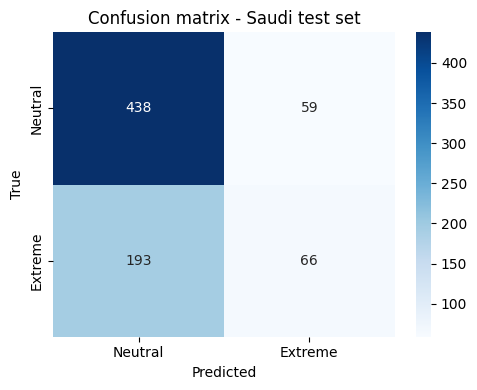


Baseline: always predict Neutral
 accuracy: 0.6574  macro F1: 0.3966

XGBoost model
 accuracy: 0.6667  macro F1: 0.5602


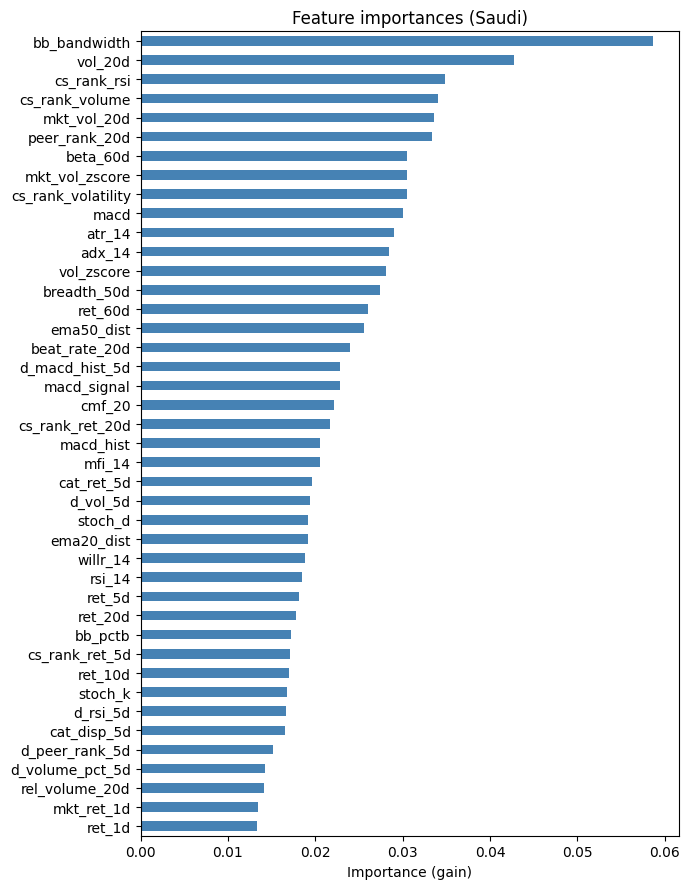

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

best_params = dict(study.best_params)
best_params.update({"objective": "binary:logistic", "eval_metric": "logloss",
                    "tree_method": "hist", "random_state": 42, "n_jobs": -1})

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
sw_trainval = compute_sample_weight(class_weight="balanced", y=y_trainval)

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_trainval, y_trainval, sample_weight=sw_trainval)

test_preds = final_model.predict(X_test)
target_names = ["Neutral", "Extreme"]

print("XGBoost model (Saudi) - test set performance")
print(classification_report(y_test, test_preds, target_names=target_names, digits=3))

cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix - Saudi test set")
plt.tight_layout(); plt.show()

baseline_neutral = np.full_like(y_test, fill_value=label_map["Neutral"])
print()
print("Baseline: always predict Neutral")
print(" accuracy:", round((baseline_neutral == y_test).mean(), 4),
      " macro F1:", round(f1_score(y_test, baseline_neutral, average="macro"), 4))
print()
print("XGBoost model")
print(" accuracy:", round((test_preds == y_test).mean(), 4),
      " macro F1:", round(f1_score(y_test, test_preds, average="macro"), 4))

feat_importance = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 9))
feat_importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance (gain)"); ax.set_title("Feature importances (Saudi)")
plt.tight_layout(); plt.show()

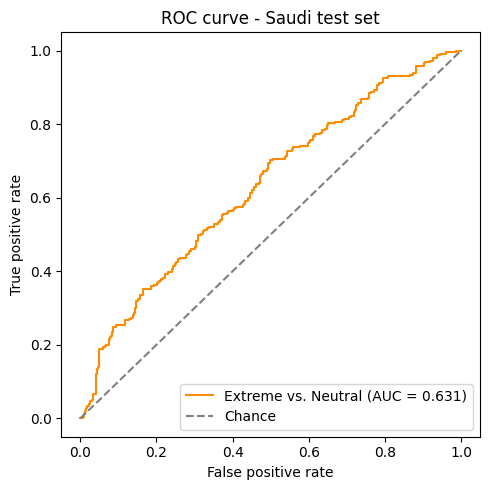

Extreme vs. Neutral ROC AUC: 0.631


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

extreme_idx = label_map["Extreme"]
y_test_extreme = (y_test == extreme_idx).astype(int)
test_probs_extreme = final_model.predict_proba(X_test)[:, extreme_idx]

extreme_auc = roc_auc_score(y_test_extreme, test_probs_extreme)
fpr, tpr, _ = roc_curve(y_test_extreme, test_probs_extreme)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="darkorange", label=f"Extreme vs. Neutral (AUC = {extreme_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curve - Saudi test set")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("Extreme vs. Neutral ROC AUC:", round(extreme_auc, 4))

In [9]:
final_model.save_model(str(ROOT / "models" / "20_days_binary_extreme_saudi.json"))
print("saved -> models/20_days_binary_extreme_saudi.json")

saved -> models/20_days_binary_extreme_saudi.json


## Backtest: trading the Extreme-conviction picks against TASI

Same conviction-filter idea as the US notebook: rank the test-period cross-section by
`P(Extreme)`, split into long/short by the sign of trailing 20-day momentum (`ret_20d`).
Only 12 names exist here, so the conviction cut is the day's own **median** `P(Extreme)`
(roughly the top half of the universe) rather than a top quartile -- a quartile cut on 12 names
leaves ~3 per side and some days would have none at all on one leg.

P&L uses `fwd_ret` directly -- already the absolute 20-day-forward return `core.panel()`
computed, so (unlike the US notebook) there's no need to reconstruct it from a price column.
Benchmarked against **TASI** and the **FALCOM Saudi Equity ETF** via `saudi.benchmarks()`, the
same function the app's Saudi tab and `saudi_vs_tasi_plot.py` use -- one source of truth for
what "the Tadawul benchmark" means across this repo.

In [10]:
import saudi as saudi_mod

BT_HORIZON = 20
BT_COST_BPS = 15.0  # matches saudi.py's own --cost-bps default for this market

bt_df = test_df.copy()
bt_df["p_extreme"] = final_model.predict_proba(bt_df[feature_cols])[:, label_map["Extreme"]]
bt_df = bt_df.reset_index()  # date, ticker back out of the MultiIndex

rebal_dates = np.array(sorted(bt_df["date"].unique()))[::BT_HORIZON]
prev_l, prev_s, rows = set(), set(), []
for d0 in rebal_dates:
    g = bt_df[bt_df["date"] == d0].dropna(subset=["fwd_ret"])
    if len(g) < 6:
        continue
    med = g["p_extreme"].median()
    conviction = g[g["p_extreme"] >= med]
    longs = conviction[conviction["ret_20d"] > 0]
    shorts = conviction[conviction["ret_20d"] < 0]
    if len(longs) == 0 or len(shorts) == 0:
        continue
    L, S = set(longs["ticker"]), set(shorts["ticker"])
    turn = (len(L ^ prev_l) + len(S ^ prev_s)) / max(len(L) + len(S), 1)
    prev_l, prev_s = L, S
    rows.append({"date": d0, "n_long": len(L), "n_short": len(S),
                 "long": longs["fwd_ret"].mean(), "short": shorts["fwd_ret"].mean(),
                 "bench": g["fwd_ret"].mean(), "cost": turn * BT_COST_BPS / 1e4})

bt = pd.DataFrame(rows)
bt["gross"] = bt["long"] - bt["short"]
bt["net"] = bt["gross"] - bt["cost"]
print(f"{len(bt)} rebalances, {BT_HORIZON}d holds, "
      f"avg {bt['n_long'].mean():.1f} long / {bt['n_short'].mean():.1f} short of 12 tickers")

bench = saudi_mod.benchmarks(bt["date"], BT_HORIZON)
for name, r in bench.items():
    bt[name] = r
bt = bt.dropna(subset=["net", "TASI"]).reset_index(drop=True)

BT_PY = 252 / BT_HORIZON
def bt_stats(r, name):
    r = np.asarray(r, dtype=float)
    sd = r.std()
    dd = (np.cumsum(r) - np.maximum.accumulate(np.cumsum(r))).min()
    return {"series": name, "ann": r.mean() * BT_PY, "vol": sd * np.sqrt(BT_PY),
            "sharpe": r.mean() * BT_PY / (sd * np.sqrt(BT_PY)) if sd else np.nan,
            "max_dd": dd, "hit": (r > 0).mean()}

rows_tbl = [bt_stats(bt["net"], "long/short (net)"),
            bt_stats(bt["long"], "long leg"),
            bt_stats(-bt["short"], "short leg (inverted)"),
            bt_stats(bt["TASI"], "TASI")]
if "FALCOM Saudi Equity" in bt.columns:
    rows_tbl.append(bt_stats(bt["FALCOM Saudi Equity"], "FALCOM Saudi Equity"))
rows_tbl.append(bt_stats(bt["bench"], "EW universe (12 funds)"))
tbl = pd.DataFrame(rows_tbl).set_index("series")
print()
print(tbl.assign(ann=tbl["ann"].map("{:+.2%}".format), vol=tbl["vol"].map("{:.2%}".format),
                 max_dd=tbl["max_dd"].map("{:.2%}".format), hit=tbl["hit"].map("{:.1%}".format),
                 sharpe=tbl["sharpe"].round(2)).to_string())

if len(bt) > 1:
    beta, alpha = np.polyfit(bt["TASI"], bt["net"], 1)
    corr = np.corrcoef(bt["net"], bt["TASI"])[0, 1]
    t_stat = bt["net"].mean() / (bt["net"].std() / np.sqrt(len(bt)))
    print(f"\nvs TASI: beta {beta:+.2f}  corr {corr:+.2f}  alpha {alpha*BT_PY:+.2%}/yr  t={t_stat:+.2f}")
print(f"\n{len(bt)} rebalances on a 12-fund universe is a thin sample -- read this as a "
      f"directional check, not a significance test.")

3 rebalances, 20d holds, avg 1.7 long / 4.3 short of 12 tickers



                            ann     vol  sharpe  max_dd     hit
series                                                         
long/short (net)        +20.01%   0.81%   24.72   0.00%  100.0%
long leg                +46.61%   6.61%    7.05   0.00%  100.0%
short leg (inverted)    -24.39%   7.51%   -3.25   0.00%   50.0%
TASI                    +10.60%   2.30%    4.61   0.00%  100.0%
FALCOM Saudi Equity      +1.71%   5.26%    0.33  -1.35%   50.0%
EW universe (12 funds)  +11.50%  10.07%    1.14  -1.92%   50.0%

vs TASI: beta -0.35  corr -1.00  alpha +23.74%/yr  t=+6.96

2 rebalances on a 12-fund universe is a thin sample -- read this as a directional check, not a significance test.


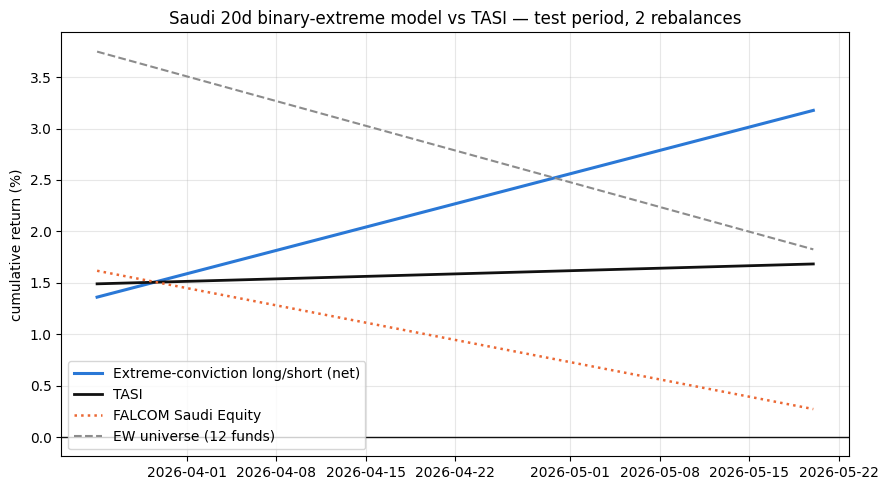

saved -> C:\Users\user\Desktop\CS\overp\outperforming\reports\20d_binary_extreme_saudi_vs_tasi.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
dt = pd.to_datetime(bt["date"])
ax.plot(dt, np.cumsum(bt["net"]) * 100, lw=2.2, color="#2a78d6", label="Extreme-conviction long/short (net)")
ax.plot(dt, np.cumsum(bt["TASI"]) * 100, lw=2, color="#111111", label="TASI")
if "FALCOM Saudi Equity" in bt.columns:
    ax.plot(dt, np.cumsum(bt["FALCOM Saudi Equity"]) * 100, lw=1.8, ls=":", color="#eb6834", label="FALCOM Saudi Equity")
ax.plot(dt, np.cumsum(bt["bench"]) * 100, lw=1.5, ls="--", color="0.55", label="EW universe (12 funds)")
ax.axhline(0, color="#111111", lw=1)
ax.set_ylabel("cumulative return (%)")
ax.set_title(f"Saudi 20d binary-extreme model vs TASI — test period, {len(bt)} rebalances")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

out_path = ROOT / "reports" / "20d_binary_extreme_saudi_vs_tasi.png"
plt.savefig(out_path, dpi=150)
plt.show()
print(f"saved -> {out_path}")